/home/ssn/miniconda3/envs/openmc-env/lib/python3.10/site-packages/openmc/material.py:787: UserWarning: A uranium enrichment of 6 was given for Material ID="3". OpenMC assumes the U234/U235 mass ratio is constant at 0.008, which is only valid at low enrichments. Consider setting the isotopic composition manually for enrichments over 5%.
  warnings.warn(msg)


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

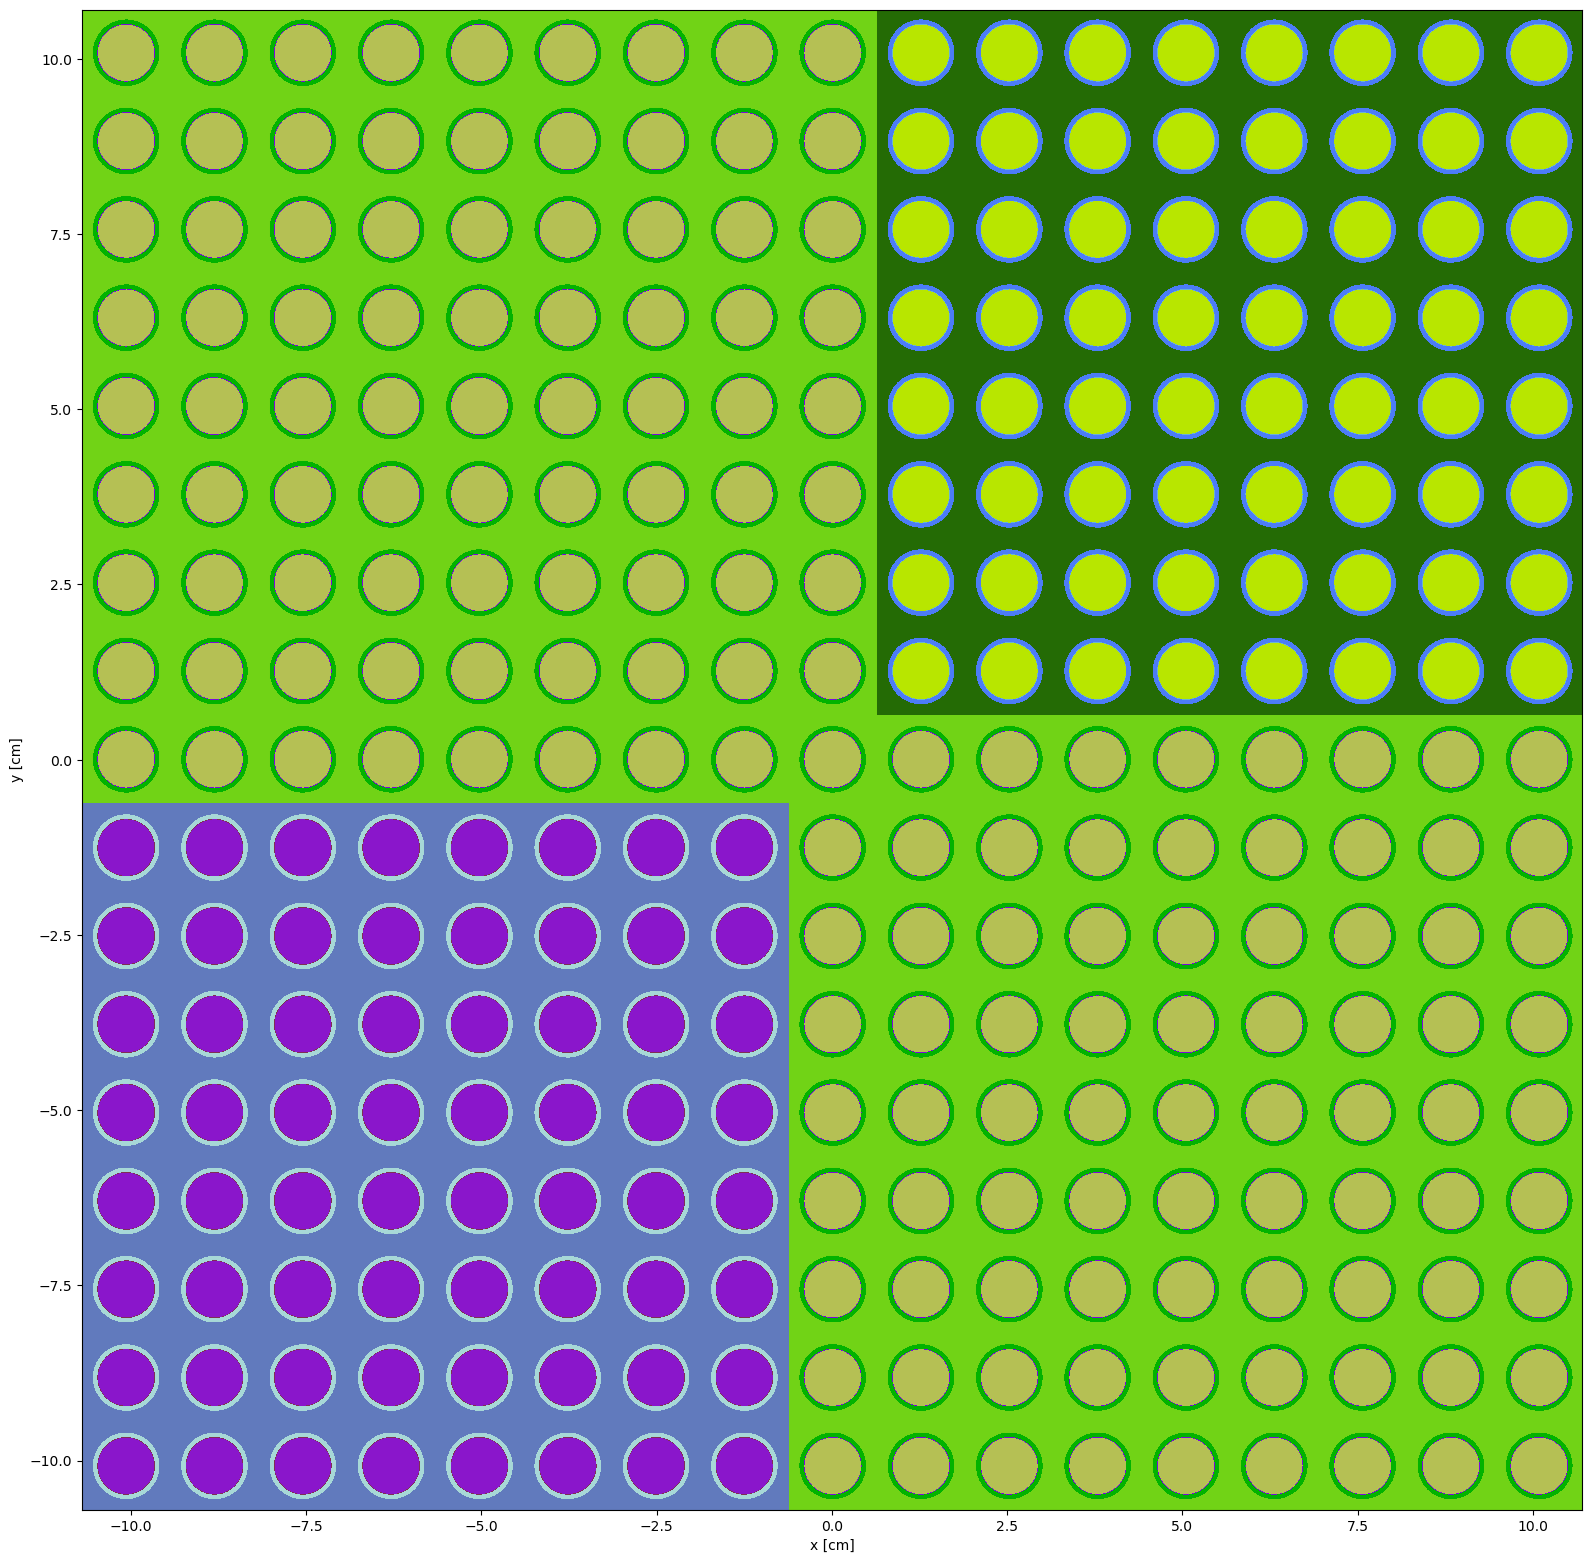

In [1]:
from math import pi

import openmc
import openmc.deplete
import numpy as np



uo2 = openmc.Material(name='UO2 fuel1')
uo2.temperature = 900.0
uo2.set_density('g/cm3', 10.412)

uo2.add_element('U', 1, enrichment=2, enrichment_type='wo')
uo2.add_element('O', 2)

xuo2 = openmc.Material(name='UO2 fuel2')
xuo2.temperature = 900.0
xuo2.set_density('g/cm3', 10.412)

xuo2.add_element('U', 1, enrichment=4, enrichment_type='wo')
xuo2.add_element('O', 2)

yuo2 = openmc.Material(name='UO2 fuel3')
yuo2.temperature = 900.0
yuo2.set_density('g/cm3', 10.412)

yuo2.add_element('U', 1, enrichment=6, enrichment_type='wo')
yuo2.add_element('O', 2)

helium = openmc.Material(name='Helium for gap')
helium.temperature = 800
helium.set_density('g/cm3', 0.001598)
helium.add_element('He', 2.4044e-4)

ss304 = openmc.Material(name='SS304')
ss304.temperature = 560
ss304.set_density('g/cc', 6.6)
ss304.add_element('Zr', 1.0)

borated_water = openmc.model.borated_water(680.916772554002,temperature=594.14,temp_unit='K',density=0.6775, name = "water")
borated_water.temperature=594.14
borated_water.add_s_alpha_beta('c_H_in_H2O')

# materials = openmc.Materials([gd_o_uo2, gd_uo2, uo2, helium, ss304, borated_water])
# materials.export_to_xml()
###############################################################################
#                             Create geometry
###############################################################################

# Define surfaces
pin_pitch =1.26
fuel_inner_radius = 0.0
fuel_outer_radius =0.805/2
clad_inner_radius = 0.822/2
clad_outer_radius = 0.95/2

fuel_or = openmc.ZCylinder(r=fuel_outer_radius, name='Fuel OR')
clad_ir = openmc.ZCylinder(r=clad_inner_radius, name='Clad IR')
clad_or = openmc.ZCylinder(r=clad_outer_radius, name='Clad OR')

gt_ir = openmc.ZCylinder(r=0.5715, name='guide tube IR')
gt_or = openmc.ZCylinder(r=0.6121, name='guide tube OR')


# Define uo2 cells
fuel = openmc.Cell(fill=uo2, region=-fuel_or, name = 'UO2 fuel1 cell')
gap = openmc.Cell(fill=helium, region=+fuel_or & -clad_ir, name = "gap1")
clad = openmc.Cell(fill=ss304, region=+clad_ir & -clad_or, name = "clad1")
water = openmc.Cell(fill=borated_water, region=+clad_or, name = "coolant1")

# Define uo2 cells
fuel1 = openmc.Cell(fill=xuo2, region=-fuel_or, name = 'UO2 fuel2 cell')
gap1 = openmc.Cell(fill=helium, region=+fuel_or & -clad_ir, name = "gap2")
clad1 = openmc.Cell(fill=ss304, region=+clad_ir & -clad_or, name = "clad2")
water1 = openmc.Cell(fill=borated_water, region=+clad_or, name = "coolant2")

# Define uo2 cells
fuel2 = openmc.Cell(fill=yuo2, region=-fuel_or, name = 'UO2 fuel3 cell')
gap2 = openmc.Cell(fill=helium, region=+fuel_or & -clad_ir, name = "gap3")
clad2 = openmc.Cell(fill=ss304, region=+clad_ir & -clad_or, name = "clad3")
water2 = openmc.Cell(fill=borated_water, region=+clad_or, name = "coolant3")


materials = openmc.Materials([uo2, xuo2, yuo2, helium, ss304, borated_water])
materials.export_to_xml()

# gd_o_gap = openmc.Cell(fill=helium, region=+fuel_or & -clad_ir)
# gd_o_clad = openmc.Cell(fill=ss304, region=+clad_ir & -clad_or)
# gd_o_water = openmc.Cell(fill=borated_water, region=+clad_or)


# Define pin universe
uo2_universe = openmc.Universe(cells=[fuel, gap, clad, water], name = "uo2_universe")
xuo2_universe = openmc.Universe(cells=[fuel1, gap1, clad1, water1], name = "xuo2_universe")
yuo2_universe = openmc.Universe(cells=[fuel2, gap2, clad2, water2], name = "yuo2_universe")


pin_boundary = openmc.model.RectangularPrism(pin_pitch, pin_pitch)
assembly_pitch = 21.4
assembly_boundary = openmc.model.RectangularPrism(assembly_pitch, assembly_pitch, boundary_type='reflective')

fuel_lat = openmc.RectLattice(name="sf96_1 assembly")
fuel_lat.center = (0., 0.)
fuel_lat.pitch = (pin_pitch, pin_pitch)
fuel_lat.lower_left = [-assembly_pitch/2, -assembly_pitch/2]
# coolant universe for empty pin space filling
coolant_cell = openmc.Cell(fill=borated_water, name = "lattice outer water cell")
coolant_u = openmc.Universe(cells=[coolant_cell], name = "lattice outer water universe")
fuel_lat.outer = coolant_u

u0 = uo2_universe
ux = xuo2_universe
uy = yuo2_universe

fuel_lat.universes = [  
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, uy, uy, uy, uy, uy, uy, uy, uy],
                        [u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                        [ux, ux, ux, ux, ux, ux, ux, ux, u0, u0, u0, u0, u0, u0, u0, u0, u0],
                    ]

fuel_lat_cell = openmc.Cell(fill=fuel_lat,region=-assembly_boundary, name = "fuel lattice")

geometry = openmc.Geometry([fuel_lat_cell])
geometry.export_to_xml()
fuel_lat_cell.plot(origin=(0., 0., 0.), pixels=(1500, 1500), color_by='cell')
